In [ ]:
!pip install datasets rouge-score nltk tqdm matplotlib seaborn gensim -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 72.6 MB/s eta 0:00:00


In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, random, os, itertools, time, pickle
from multiprocessing import Pool
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm.notebook import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Paper hyperparams (Section 5); train scale-down cho Colab, test = full split.
N_TRAIN, N_VAL            = 50000, 2000
N_TEST                    = None
EMB_DIM,  LSTM_HID        = 200,   600
MAX_DOC_LEN, MAX_SENT_LEN = 120,   100
EPOCHS_RL, BATCH_SIZE     = 10,    32
LR                        = 1e-3
GRAD_CLIP                 = 5.0
VOCAB_SIZE                = 50000
USE_AMP                   = torch.cuda.is_available()

SENT_EMB    = 350
NUM_KERNELS = 7
assert SENT_EMB % NUM_KERNELS == 0

m, p, k = 3, 10, 5

# rougeLsum + Porter stemmer khớp pyrouge của paper; False -> rougeL/no-stemmer.
FAITHFUL_ROUGE = True

SAVE_DIR = './refresh_ckpt'
os.makedirs(SAVE_DIR, exist_ok=True)

print(f'Train/Val = {N_TRAIN}/{N_VAL} | Test = FULL split' if N_TEST is None else f'Train/Val/Test = {N_TRAIN}/{N_VAL}/{N_TEST}')
print(f'EMB={EMB_DIM}, LSTM_HID={LSTM_HID}, m={m}, p={p}, k={k}, LR={LR}, AMP={USE_AMP}')
print(f'Checkpoints: {SAVE_DIR}')

Device: cuda
GPU: NVIDIA L4
Train/Val = 50000/2000 | Test = FULL split
EMB=200, LSTM_HID=600, m=3, p=10, k=5, LR=0.001, AMP=True
Checkpoints: ./refresh_ckpt


In [ ]:
import nltk
nltk.download('punkt', quiet=True); nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize, word_tokenize
from datasets import load_dataset
from collections import Counter

print('Loading CNN/DailyMail...')
raw = load_dataset('abisee/cnn_dailymail', '3.0.0')

def tokenize_doc(text, max_sents, max_words):
    # lower-case để khớp GloVe uncased
    sents = sent_tokenize(text)[:max_sents]
    return [word_tokenize(s.lower())[:max_words] for s in sents]

def tokenize_highlights(text):
    return word_tokenize(text.lower())[:200]

train_raw = list(raw['train'])[:N_TRAIN]
val_raw   = list(raw['validation'])[:N_VAL]
test_raw  = list(raw['test']) if N_TEST is None else list(raw['test'])[:N_TEST]

counter = Counter()
for item in tqdm(train_raw, desc='Vocab'):
    for s in tokenize_doc(item['article'], MAX_DOC_LEN, MAX_SENT_LEN):
        counter.update(s)

PAD_ID, UNK_ID = 0, 1
vocab = ['<PAD>', '<UNK>'] + [w for w, _ in counter.most_common(VOCAB_SIZE - 2)]
word2id = {w: i for i, w in enumerate(vocab)}
ACTUAL_VOCAB_SIZE = len(vocab)
print(f'Vocab: {ACTUAL_VOCAB_SIZE}')

def encode_doc(text):
    sents = tokenize_doc(text, MAX_DOC_LEN, MAX_SENT_LEN)
    return [[word2id.get(w, UNK_ID) for w in s] + [PAD_ID] * (MAX_SENT_LEN - len(s)) for s in sents]

def process_split(raw_split, desc):
    data = []
    for item in tqdm(raw_split, desc=desc):
        doc = encode_doc(item['article'])
        if len(doc) < 2:
            continue
        data.append({
            'doc': doc,
            'raw_sents': tokenize_doc(item['article'], MAX_DOC_LEN, MAX_SENT_LEN),
            'raw_gold': item['highlights'],
        })
    return data

train_data = process_split(train_raw, 'Train')
val_data   = process_split(val_raw,   'Val')
test_data  = process_split(test_raw,  'Test')
print(f'Train={len(train_data)}, Val={len(val_data)}, Test={len(test_data)}')

Loading CNN/DailyMail...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/15.6k [00:00<?, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

...

Vocab: 50000


Train:   0%|          | 0/50000 [00:00<?, ?it/s]

Val:   0%|          | 0/2000 [00:00<?, ?it/s]

Test:   0%|          | 0/11490 [00:00<?, ?it/s]

Train=49998, Val=2000, Test=11490


In [ ]:
import gensim.downloader as api

print('Loading GloVe 200d (glove-wiki-gigaword-200)...')
glove = api.load('glove-wiki-gigaword-200')
print(f'  → {len(glove.key_to_index):,} từ, dim={glove.vector_size}')
assert glove.vector_size == EMB_DIM, f'GloVe dim {glove.vector_size} ≠ EMB_DIM {EMB_DIM}'

embedding_matrix = np.zeros((ACTUAL_VOCAB_SIZE, EMB_DIM), dtype=np.float32)
hits = 0
for word, idx in word2id.items():
    if word in glove.key_to_index:
        embedding_matrix[idx] = glove[word]
        hits += 1
embedding_matrix[PAD_ID] = 0.0

print(f'GloVe coverage: {hits:,}/{ACTUAL_VOCAB_SIZE:,} ({hits/ACTUAL_VOCAB_SIZE*100:.1f}%)')
print(f'OOV (zero-init, train end-to-end): {ACTUAL_VOCAB_SIZE - hits:,}')

del glove

Loading GloVe 200d (glove-wiki-gigaword-200)...
[==================================================] 100.0% 252.1/252.1MB downloaded
  → 400,000 từ, dim=200
GloVe coverage: 48,359/50,000 (96.7%)
OOV (zero-init, train end-to-end): 1,641


In [ ]:
from rouge_score import rouge_scorer

_RL_KEY = 'rougeLsum' if FAITHFUL_ROUGE else 'rougeL'
_scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', _RL_KEY], use_stemmer=FAITHFUL_ROUGE)

def _join_sents(sents_tokens):
    sep = chr(10) if FAITHFUL_ROUGE else ' '
    return sep.join(' '.join(w) for w in sents_tokens)

def rouge_f(candidate_text, reference_text):
    s = _scorer.score(reference_text, candidate_text)
    return (s['rouge1'].fmeasure + s['rouge2'].fmeasure + s[_RL_KEY].fmeasure) / 3.0

def compute_oracle_for_doc(item, m, p, k):
    sents, gold = item['raw_sents'], item['raw_gold']
    n = len(sents)
    if n < m:
        return [(tuple(range(n)), 0.0)]

    sent_scores = sorted(
        [(rouge_f(' '.join(s), gold), i) for i, s in enumerate(sents)],
        reverse=True
    )
    top_p_ids = sorted(idx for _, idx in sent_scores[:p])

    combo_scores = sorted(
        [(rouge_f(_join_sents([sents[i] for i in combo]), gold), combo)
         for combo in itertools.combinations(top_p_ids, m)],
        reverse=True
    )
    return [(combo, score) for score, combo in combo_scores[:k]]

def _oracle_worker(args):
    return compute_oracle_for_doc(*args)

ORACLE_CACHE = os.path.join(SAVE_DIR, f'oracles_N{len(train_data)}_m{m}_p{p}_k{k}_' + ('faithful' if FAITHFUL_ROUGE else 'raw') + '.pkl')

if os.path.exists(ORACLE_CACHE):
    print(f'Loading cached oracle: {ORACLE_CACHE}')
    with open(ORACLE_CACHE, 'rb') as f:
        train_oracles = pickle.load(f)
else:
    print(f'Computing oracle Ŷ ({len(train_data)} docs, m={m}, p={p}, k={k})...')
    t0 = time.time()
    with Pool(processes=os.cpu_count()) as pool:
        train_oracles = list(tqdm(
            pool.imap(_oracle_worker, [(item, m, p, k) for item in train_data], chunksize=50),
            total=len(train_data), desc='Oracle'
        ))
    print(f'Oracle done in {(time.time()-t0)/60:.1f} min — saving cache...')
    with open(ORACLE_CACHE, 'wb') as f:
        pickle.dump(train_oracles, f)
    print(f'Saved: {ORACLE_CACHE}')

for item, oracle in zip(train_data, train_oracles):
    item['oracles'] = oracle

avg_r = np.mean([oracle[0][1] for oracle in train_oracles if oracle])
print(f'Avg best oracle ROUGE: {avg_r:.4f}')

Computing oracle Ŷ (49998 docs, m=3, p=10, k=5)...


Oracle:   0%|          | 0/49998 [00:00<?, ?it/s]

Oracle done in 71.0 min — saving cache...
Saved: ./refresh_ckpt/oracles_N49998_m3_p10_k5_faithful.pkl
Avg best oracle ROUGE: 0.4164


In [ ]:
class SentenceEncoderCNN(nn.Module):
    """CNN sentence encoder: kernel widths 1-7, ReLU + max-over-time, concat -> sent_emb."""
    def __init__(self, emb_dim, sent_emb, num_kernels):
        super().__init__()
        ch = sent_emb // num_kernels
        self.convs = nn.ModuleList([
            nn.Conv1d(emb_dim, ch, kernel_size=w) for w in range(1, num_kernels + 1)
        ])

    def forward(self, x):
        x = x.transpose(1, 2)
        return torch.cat([F.relu(c(x)).max(dim=2).values for c in self.convs], dim=1)


class REFRESHModel(nn.Module):
    """REFRESH (paper Figure 1): CNN sentence encoder -> document LSTM (reversed,
    final state only) -> sentence-extractor LSTM (init from doc state) -> Linear(2)."""
    def __init__(self, vocab_size, emb_dim, sent_emb, lstm_hid, num_kernels,
                 pad_id=0, pretrained_emb=None):
        super().__init__()
        self.pad_id = pad_id
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        if pretrained_emb is not None:
            assert pretrained_emb.shape == (vocab_size, emb_dim), \
                f'pretrained_emb shape {pretrained_emb.shape} ≠ ({vocab_size}, {emb_dim})'
            self.embedding.weight.data.copy_(torch.from_numpy(pretrained_emb))
        self.sent_enc  = SentenceEncoderCNN(emb_dim, sent_emb, num_kernels)
        self.doc_lstm  = nn.LSTM(sent_emb, lstm_hid, batch_first=True)
        self.ext_lstm  = nn.LSTM(sent_emb, lstm_hid, batch_first=True)
        self.classifier = nn.Linear(lstm_hid, 2)

    def forward(self, docs):
        B, S, T = docs.shape
        mask = (docs != self.pad_id).any(dim=-1)

        x = self.embedding(docs.view(B * S, T))
        s = self.sent_enc(x).view(B, S, -1)

        _, (h_doc, c_doc) = self.doc_lstm(torch.flip(s, [1]))

        ext_out, _ = self.ext_lstm(s, (h_doc, c_doc))

        logits = self.classifier(ext_out)
        return logits, mask


model = REFRESHModel(
    vocab_size=ACTUAL_VOCAB_SIZE, emb_dim=EMB_DIM,
    sent_emb=SENT_EMB, lstm_hid=LSTM_HID, num_kernels=NUM_KERNELS,
    pretrained_emb=embedding_matrix,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Params: {n_params:,}')
print(f'Architecture (faithful paper Figure 1):')
print(f'  [B,S,T] → embed (GloVe init) → CNN → sent_reps [B,S,{SENT_EMB}]')
print(f'  sent_reps ──flip──> doc_LSTM → final (h,c)   (discard outputs)')
print(f'  sent_reps ─────────> ext_LSTM(init=(h,c)) → [B,S,{LSTM_HID}] → Linear → [B,S,2]')

Params: 14,851,152
Architecture (faithful paper Figure 1):
  [B,S,T] → embed (GloVe init) → CNN → sent_reps [B,S,350]
  sent_reps ──flip──> doc_LSTM → final (h,c)   (discard outputs)
  sent_reps ─────────> ext_LSTM(init=(h,c)) → [B,S,600] → Linear → [B,S,2]


In [ ]:
def lead_summary(raw_sents, m):
    return raw_sents[:m]

def evaluate_rouge(pred_sents_list, gold_texts):
    r1, r2, rl = [], [], []
    for sents, gold in zip(pred_sents_list, gold_texts):
        s = _scorer.score(gold, _join_sents(sents))
        r1.append(s['rouge1'].fmeasure)
        r2.append(s['rouge2'].fmeasure)
        rl.append(s[_RL_KEY].fmeasure)
    return {'ROUGE-1': np.mean(r1)*100, 'ROUGE-2': np.mean(r2)*100, 'ROUGE-L': np.mean(rl)*100}

lead_scores = evaluate_rouge(
    [lead_summary(item['raw_sents'], m) for item in test_data],
    [item['raw_gold'] for item in test_data]
)
print('LEAD:', {kk: f'{v:.2f}' for kk, v in lead_scores.items()})


LEAD: {'ROUGE-1': '40.03', 'ROUGE-2': '17.46', 'ROUGE-L': '36.33'}


In [ ]:
from torch.utils.data import Dataset, DataLoader

class REFRESHDataset(Dataset):
    def __init__(self, data, has_oracle=False):
        self.data = data
        self.has_oracle = has_oracle

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        doc_tensor = torch.zeros(MAX_DOC_LEN, MAX_SENT_LEN, dtype=torch.long)
        weight = torch.zeros(MAX_DOC_LEN)
        for i, sent in enumerate(item['doc'][:MAX_DOC_LEN]):
            doc_tensor[i, :len(sent)] = torch.tensor(sent[:MAX_SENT_LEN], dtype=torch.long)
            weight[i] = 1.0

        result = {'doc': doc_tensor, 'weight': weight}

        if self.has_oracle:
            oracle_indices, reward = item['oracles'][random.randint(0, len(item['oracles']) - 1)]
            label = torch.ones(MAX_DOC_LEN, dtype=torch.long)
            for oi in oracle_indices:
                if oi < MAX_DOC_LEN:
                    label[oi] = 0
            result['oracle_label'] = label
            result['reward'] = torch.tensor(reward, dtype=torch.float)

        return result

train_loader = DataLoader(REFRESHDataset(train_data, has_oracle=True), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(REFRESHDataset(val_data),                    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(REFRESHDataset(test_data),                   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Batches: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}')

Batches: train=1563, val=63, test=360


In [ ]:
from torch.cuda.amp import autocast, GradScaler

def reward_weighted_ce_loss(logits, oracle_label, reward, weight):
    B, S, _ = logits.shape
    ce = F.cross_entropy(logits.view(B*S, 2), oracle_label.view(B*S), reduction='none')
    ce = ce.view(B, S) * weight
    return (ce.sum(dim=1) * reward).mean()

def predict_topm(logits, weight, m):
    probs = F.softmax(logits, dim=-1)[:, :, 0] * weight
    topk  = torch.topk(probs, k=min(m, probs.size(1)), dim=1)
    return [sorted(topk.indices[b].tolist()[:m]) for b in range(logits.size(0))]

def eval_rouge(model, data_list, loader, m):
    model.eval()
    preds, golds, idx = [], [], 0
    with torch.no_grad():
        for batch in loader:
            with autocast(enabled=USE_AMP):
                logits, _ = model(batch['doc'].to(device))
            for b, sent_ids in enumerate(predict_topm(logits.float(), batch['weight'].to(device), m)):
                item = data_list[idx + b]
                preds.append([item['raw_sents'][i] for i in sent_ids if i < len(item['raw_sents'])])
                golds.append(item['raw_gold'])
            idx += logits.size(0)
    return evaluate_rouge(preds, golds)


optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scaler    = GradScaler(enabled=USE_AMP)

BEST_CKPT = os.path.join(SAVE_DIR, 'refresh_best.pt')
LAST_CKPT = os.path.join(SAVE_DIR, 'refresh_last.pt')

CFG_HAS_PRETRAINED_EMB = True
CFG_VOCAB_SIZE         = ACTUAL_VOCAB_SIZE
FORCE_FRESH = False
if os.path.exists(LAST_CKPT):
    try:
        ck_peek = torch.load(LAST_CKPT, map_location='cpu', weights_only=False)
        ckpt_lr     = ck_peek['optim']['param_groups'][0]['lr']
        ckpt_emb    = ck_peek.get('has_pretrained_emb', False)
        ckpt_vocab  = ck_peek.get('vocab_size', None)
        if abs(ckpt_lr - LR) > 1e-9:
            print(f'⚠️  LR trong checkpoint ({ckpt_lr}) ≠ LR config ({LR}) → fresh start.')
            FORCE_FRESH = True
        elif ckpt_emb != CFG_HAS_PRETRAINED_EMB:
            print(f'⚠️  Checkpoint cũ has_pretrained_emb={ckpt_emb} nhưng config={CFG_HAS_PRETRAINED_EMB} → fresh start.')
            FORCE_FRESH = True
        elif ckpt_vocab is None or ckpt_vocab != CFG_VOCAB_SIZE:
            print(f'⚠️  Vocab size trong checkpoint ({ckpt_vocab}) ≠ config ({CFG_VOCAB_SIZE}) → fresh start.')
            FORCE_FRESH = True
        del ck_peek
    except Exception as e:
        print(f'⚠️  Không đọc được checkpoint cũ ({e}) → fresh start.')
        FORCE_FRESH = True

if FORCE_FRESH:
    for f in (LAST_CKPT, BEST_CKPT):
        if os.path.exists(f):
            os.remove(f)

start_epoch       = 1
train_losses      = []
val_rouge_history = []
best_val_r1       = -1.0
best_epoch        = 0

if os.path.exists(LAST_CKPT):
    try:
        print(f'Resume từ {LAST_CKPT}...')
        ck = torch.load(LAST_CKPT, map_location=device, weights_only=False)
        model.load_state_dict(ck['model'])
        optimizer.load_state_dict(ck['optim'])
        if 'scaler' in ck and USE_AMP and ck['scaler'] is not None:
            scaler.load_state_dict(ck['scaler'])
        start_epoch       = ck['epoch'] + 1
        train_losses      = ck.get('train_losses', [])
        val_rouge_history = ck.get('val_rouge_history', [])
        best_val_r1       = ck.get('best_val_r1', -1.0)
        best_epoch        = ck.get('best_epoch', 0)
        print(f'  → resuming from epoch {start_epoch}, best val R1 so far = {best_val_r1:.2f}')
    except (RuntimeError, KeyError) as e:
        print(f'⚠️  Checkpoint cũ không tương thích — xóa và train lại từ đầu.\n   Error: {e}')
        for f in (LAST_CKPT, BEST_CKPT):
            if os.path.exists(f):
                os.remove(f)
        start_epoch = 1
        train_losses, val_rouge_history = [], []
        best_val_r1, best_epoch = -1.0, 0

print(f'\nTraining REFRESH: {EPOCHS_RL} epochs × {len(train_loader)} batches | LR={LR} | AMP={USE_AMP} | batch={BATCH_SIZE}')
t_start = time.time()

epoch_bar = tqdm(range(start_epoch, EPOCHS_RL + 1), desc='Epochs', position=0)
for epoch in epoch_bar:
    model.train()
    losses = []
    inner_bar = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS_RL}', leave=False, position=1)
    for batch in inner_bar:
        docs   = batch['doc'].to(device, non_blocking=True)
        weight = batch['weight'].to(device, non_blocking=True)
        label  = batch['oracle_label'].to(device, non_blocking=True)
        reward = batch['reward'].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=USE_AMP):
            logits, _ = model(docs)
            loss = reward_weighted_ce_loss(logits, label, reward, weight)

        if USE_AMP:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

        losses.append(loss.item())
        inner_bar.set_postfix(loss=f'{loss.item():.3f}')

    avg_loss = np.mean(losses)
    train_losses.append(avg_loss)
    val_s = eval_rouge(model, val_data, val_loader, m)
    val_rouge_history.append(val_s)

    marker = ''
    if val_s['ROUGE-1'] > best_val_r1:
        best_val_r1 = val_s['ROUGE-1']
        best_epoch  = epoch
        torch.save(model.state_dict(), BEST_CKPT)
        marker = '  ★ best'

    torch.save({
        'epoch': epoch, 'model': model.state_dict(), 'optim': optimizer.state_dict(),
        'scaler': scaler.state_dict() if USE_AMP else None,
        'train_losses': train_losses, 'val_rouge_history': val_rouge_history,
        'best_val_r1': best_val_r1, 'best_epoch': best_epoch,
        'has_pretrained_emb': CFG_HAS_PRETRAINED_EMB,
        'vocab_size':         CFG_VOCAB_SIZE,
    }, LAST_CKPT)

    elapsed   = time.time() - t_start
    done      = epoch - start_epoch + 1
    remaining = EPOCHS_RL - epoch
    eta_sec   = (elapsed / done) * remaining if done > 0 else 0

    epoch_bar.set_postfix({
        'loss': f'{avg_loss:.3f}', 'val_R1': f'{val_s["ROUGE-1"]:.2f}',
        'best': f'{best_val_r1:.2f}@ep{best_epoch}',
        'elapsed': f'{elapsed/60:.1f}m', 'ETA': f'{eta_sec/60:.1f}m',
    })
    print(f'Epoch {epoch}: loss={avg_loss:.4f} | Val R1={val_s["ROUGE-1"]:.2f} R2={val_s["ROUGE-2"]:.2f} RL={val_s["ROUGE-L"]:.2f} | elapsed={elapsed/60:.1f}m ETA={eta_sec/60:.1f}m{marker}')

model.load_state_dict(torch.load(BEST_CKPT, map_location=device))
print(f'\n✓ Done in {(time.time()-t_start)/60:.1f} min | Best: epoch {best_epoch} | Val R1={best_val_r1:.2f}')
print(f'  Best ckpt:  {BEST_CKPT}')
print(f'  Last ckpt:  {LAST_CKPT}')


Training REFRESH: 10 epochs × 1563 batches | LR=0.001 | AMP=True | batch=32


/tmp/ipykernel_22790/3430485658.py:34: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=USE_AMP)


Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10:   0%|          | 0/1563 [00:00<?, ?it/s]

/tmp/ipykernel_22790/3430485658.py:121: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
/tmp/ipykernel_22790/3430485658.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


...

Epoch 8: loss=2.1820 | Val R1=31.47 R2=11.42 RL=28.24 | elapsed=37.4m ETA=9.4m


Epoch 9/10:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 9: loss=2.0869 | Val R1=31.45 R2=11.50 RL=28.25 | elapsed=42.1m ETA=4.7m


Epoch 10/10:   0%|          | 0/1563 [00:00<?, ?it/s]

Epoch 10: loss=2.0178 | Val R1=31.90 R2=11.82 RL=28.70 | elapsed=46.7m ETA=0.0m

✓ Done in 46.7 min | Best: epoch 1 | Val R1=34.37
  Best ckpt:  ./refresh_ckpt/refresh_best.pt
  Last ckpt:  ./refresh_ckpt/refresh_last.pt


In [ ]:
refresh_scores = eval_rouge(model, test_data, test_loader, m)

results_df = pd.DataFrame({
    'Model':   ['LEAD', 'REFRESH'],
    'ROUGE-1': [lead_scores['ROUGE-1'], refresh_scores['ROUGE-1']],
    'ROUGE-2': [lead_scores['ROUGE-2'], refresh_scores['ROUGE-2']],
    'ROUGE-L': [lead_scores['ROUGE-L'], refresh_scores['ROUGE-L']],
}).set_index('Model')

print('── Kết quả thực nghiệm ──')
print(results_df.round(2).to_string())
print()
print('── Tham chiếu paper Table 2 (full CNN+DailyMail) ──')
print(pd.DataFrame({'LEAD': [39.6,17.7,36.2], 'REFRESH':[40.0,18.2,36.6]},
                   index=['ROUGE-1','ROUGE-2','ROUGE-L']).to_string())

/tmp/ipykernel_22790/3430485658.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


── Kết quả thực nghiệm ──
         ROUGE-1  ROUGE-2  ROUGE-L
Model                             
LEAD       40.03    17.46    36.33
REFRESH    39.95    17.40    36.35

── Tham chiếu paper Table 2 (full CNN+DailyMail) ──
         LEAD  REFRESH
ROUGE-1  39.6     40.0
ROUGE-2  17.7     18.2
ROUGE-L  36.2     36.6


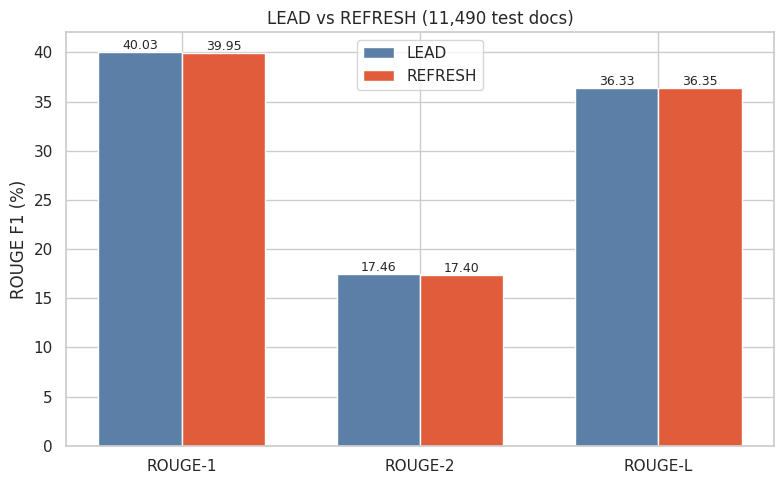

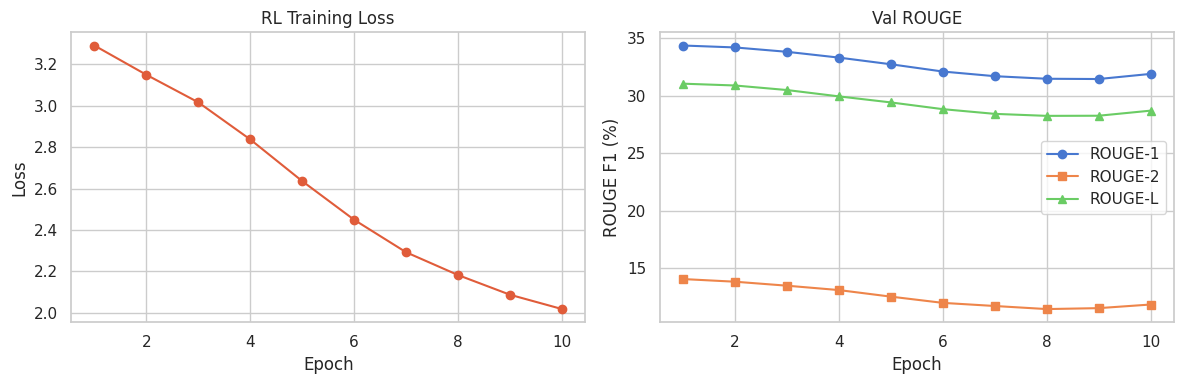


[GOLD]
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis ....

[LEAD]
  [1] ( cnn ) the palestinian authority officially became the 123rd member of the international criminal court on wednesday , a step that gives the court ju
  [2] the formal accession was marked with a ceremony at the hague , in the netherlands , where the court is based .
  [3] the palestinians signed the icc 's founding rome statute in january , when they also accepted its jurisdiction over alleged crimes committed `` in the

[REFRESH] câu [0, 1, 2]
  [1] ( cnn ) the palestinian authority officially became the 123rd member of the international criminal court on wednesday , a step that gives the court ju
  [2] the formal accession was marked with a ceremony at the hague , in the netherlands , where the court is based .
  [3] the palesti

In [ ]:
sns.set_theme(style='whitegrid', palette='muted')
os.makedirs('charts', exist_ok=True)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
metrics_list = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
x, w = np.arange(3), 0.35
b1 = ax.bar(x - w/2, [lead_scores[kk]   for kk in metrics_list], w, label='LEAD', color='#5B7FA6')
b2 = ax.bar(x + w/2, [refresh_scores[kk] for kk in metrics_list], w, label='REFRESH', color='#E05C3A')
ax.set_xticks(x); ax.set_xticklabels(metrics_list); ax.set_ylabel('ROUGE F1 (%)')
ax.set_title(f'LEAD vs REFRESH ({len(test_data):,} test docs)'); ax.legend()
ax.bar_label(b1, fmt='%.2f', fontsize=9); ax.bar_label(b2, fmt='%.2f', fontsize=9)
plt.tight_layout(); plt.savefig('charts/chart_comparison.png', dpi=150, bbox_inches='tight'); plt.show()

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(train_losses) + 1)
ax1.plot(ep, train_losses, 'o-', color='#E05C3A'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('RL Training Loss')
for key, ls in [('ROUGE-1','o-'),('ROUGE-2','s-'),('ROUGE-L','^-')]:
    ax2.plot(ep, [h[key] for h in val_rouge_history], ls, label=key)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('ROUGE F1 (%)'); ax2.set_title('Val ROUGE'); ax2.legend()
plt.tight_layout(); plt.savefig('charts/train_curves.png', dpi=150, bbox_inches='tight'); plt.show()

# Qualitative example
ex = test_data[0]
doc_t = torch.zeros(1, MAX_DOC_LEN, MAX_SENT_LEN, dtype=torch.long).to(device)
w_t   = torch.zeros(1, MAX_DOC_LEN).to(device)
for i, s in enumerate(ex['doc'][:MAX_DOC_LEN]):
    doc_t[0, i, :len(s)] = torch.tensor(s[:MAX_SENT_LEN], dtype=torch.long); w_t[0, i] = 1.0
model.eval()
with torch.no_grad():
    ref_idx = predict_topm(model(doc_t)[0], w_t, m)[0]

print(f'\n[GOLD]\n{ex["raw_gold"][:300]}...')
print('\n[LEAD]')
for i, s in enumerate(ex['raw_sents'][:m]): print(f'  [{i+1}] {" ".join(s)[:150]}')
print(f'\n[REFRESH] câu {ref_idx}')
for i in ref_idx:
    if i < len(ex['raw_sents']): print(f'  [{i+1}] {" ".join(ex["raw_sents"][i])[:150]}')

print('\nSaved: charts/chart_comparison.png, charts/train_curves.png')


In [ ]:
ex = test_data[0]
doc_t = torch.zeros(1, MAX_DOC_LEN, MAX_SENT_LEN, dtype=torch.long).to(device)
w_t   = torch.zeros(1, MAX_DOC_LEN).to(device)
for i, s in enumerate(ex['doc'][:MAX_DOC_LEN]):
    doc_t[0, i, :len(s)] = torch.tensor(s[:MAX_SENT_LEN], dtype=torch.long)
    w_t[0, i] = 1.0

model.eval()
with torch.no_grad():
    logits, _ = model(doc_t)
    probs = F.softmax(logits.float(), dim=-1)[0, :, 0] * w_t[0]

n_sent = len(ex['raw_sents'])
scores = probs[:n_sent].cpu().numpy()
order  = scores.argsort()[::-1]

print(f'Bài có {n_sent} câu — điểm P(extract) REFRESH gán cho từng câu:\n')
print(f'{"rank":<6}{"câu":<6}{"score":<10}text')
print('-' * 78)
for rank, idx in enumerate(order, 1):
    mark = '   <== CHON' if rank <= m else ''
    print(f'{rank:<6}{idx + 1:<6}{scores[idx]:<10.4f}{" ".join(ex["raw_sents"][idx])[:48]}{mark}')

print('\nTheo thứ tự câu trong bài:')
for idx in range(min(n_sent, 8)):
    print(f'  câu {idx + 1}: score = {scores[idx]:.4f}')

Bài có 27 câu — điểm P(extract) REFRESH gán cho từng câu:

rank  câu   score     text
------------------------------------------------------------------------------
1     2     0.3120    the formal accession was marked with a ceremony    <== CHON
2     1     0.2847    ( cnn ) the palestinian authority officially bec   <== CHON
3     3     0.2540    the palestinians signed the icc 's founding rome   <== CHON
4     4     0.2052    later that month , the icc opened a preliminary 
5     6     0.1560    israel and the united states , neither of which 
6     5     0.1445    as members of the court , palestinians may be su
7     7     0.1410    but palestinian foreign minister riad al-malki ,
8     24    0.1163    the war between israel and hamas militants in ga
9     22    0.1119    while a preliminary examination is not a formal 
10    25    0.1058    the inquiry will include alleged war crimes comm
11    8     0.0973    `` as palestine formally becomes a state party t
12    26    0.0942   

## Hyperparameter Sweep — m, k, lr

In [ ]:
SWEEP_EPOCHS = 3
N_SWEEP = min(2000, N_TRAIN)
sweep_train, sweep_test = train_data[:N_SWEEP], test_data[:500]   # 500 docs (SEM ≈ 0.67 R1) — đủ phân biệt diff >1.3

def run_sweep(m_val, k_val, lr_val):
    if m_val == m and k_val == k:
        _train = sweep_train
    else:
        with Pool(processes=min(4, os.cpu_count())) as pool:
            oracles = list(pool.imap(_oracle_worker, [(item, m_val, p, k_val) for item in sweep_train], chunksize=100))
        _train = [{**item, 'oracles': o} for item, o in zip(sweep_train, oracles)]

    _model = REFRESHModel(
        ACTUAL_VOCAB_SIZE, EMB_DIM, SENT_EMB, LSTM_HID, NUM_KERNELS,
        pretrained_emb=embedding_matrix,   # ← Sweep models cũng init GloVe để fair comparison
    ).to(device)
    _opt   = torch.optim.Adam(_model.parameters(), lr=lr_val)
    dl_tr  = DataLoader(REFRESHDataset(_train, has_oracle=True), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    dl_te  = DataLoader(REFRESHDataset(sweep_test),              batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    for _ in range(SWEEP_EPOCHS):
        _model.train()
        for batch in dl_tr:
            _opt.zero_grad()
            logits, _ = _model(batch['doc'].to(device))
            loss = reward_weighted_ce_loss(logits, batch['oracle_label'].to(device), batch['reward'].to(device), batch['weight'].to(device))
            loss.backward(); torch.nn.utils.clip_grad_norm_(_model.parameters(), GRAD_CLIP); _opt.step()

    return eval_rouge(_model, sweep_test, dl_te, m_val)

sweep_results = []
for m_val in [2, 3, 4]:
    print(f'm={m_val}...', end=' ', flush=True)
    s = run_sweep(m_val, k, LR)
    sweep_results.append({'param':'m','value':m_val,**s}); print(f"R1={s['ROUGE-1']:.2f}")

for k_val in [3, 5, 10]:
    print(f'k={k_val}...', end=' ', flush=True)
    s = run_sweep(m, k_val, LR)
    sweep_results.append({'param':'k','value':k_val,**s}); print(f"R1={s['ROUGE-1']:.2f}")

for lr_val in [1e-3, 5e-4]:
    print(f'lr={lr_val}...', end=' ', flush=True)
    s = run_sweep(m, k, lr_val)
    sweep_results.append({'param':'lr','value':lr_val,**s}); print(f"R1={s['ROUGE-1']:.2f}")

sweep_df = pd.DataFrame(sweep_results)
print(sweep_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (param, xlabel) in zip(axes, [('m','m (câu)'),('k','k (oracle)'),('lr','lr')]):
    sub = sweep_df[sweep_df['param'] == param]
    for key, ls in [('ROUGE-1','o-'),('ROUGE-2','s-'),('ROUGE-L','^-')]:
        ax.plot(sub['value'].astype(str), sub[key], ls, label=key)
    ax.set_xlabel(xlabel); ax.set_ylabel('ROUGE (%)'); ax.set_title(f'Sweep {param}'); ax.legend(fontsize=8)
plt.suptitle('Hyperparameter Sweep — REFRESH'); plt.tight_layout()
plt.savefig('charts/sweep_charts.png', dpi=150, bbox_inches='tight'); plt.show()
print('Saved: charts/sweep_charts.png')


In [ ]:
import json, shutil

EXPORT_DIR = os.path.join(SAVE_DIR, 'app_bundle')
os.makedirs(EXPORT_DIR, exist_ok=True)

shutil.copy(BEST_CKPT, os.path.join(EXPORT_DIR, 'refresh_best.pt'))

with open(os.path.join(EXPORT_DIR, 'vocab.json'), 'w', encoding='utf-8') as f:
    json.dump(vocab, f, ensure_ascii=False)

meta = {
    'emb_dim': EMB_DIM, 'lstm_hid': LSTM_HID, 'sent_emb': SENT_EMB,
    'num_kernels': NUM_KERNELS, 'max_doc_len': MAX_DOC_LEN, 'max_sent_len': MAX_SENT_LEN,
    'm': m, 'p': p, 'k': k, 'pad_id': PAD_ID, 'unk_id': UNK_ID, 'vocab_size': ACTUAL_VOCAB_SIZE,
    'faithful_rouge': FAITHFUL_ROUGE,
    'dataset': 'CNN/DailyMail 3.0.0',
    'embeddings': 'GloVe 200d (Wikipedia+Gigaword)',
    'n_train': len(train_data), 'n_val': len(val_data), 'n_test': len(test_data),
    'epochs': EPOCHS_RL, 'batch_size': BATCH_SIZE, 'lr': LR,
    'best_epoch': int(best_epoch), 'best_val_r1': round(float(best_val_r1), 2),
    'results': {
        'LEAD':    {kk: round(float(v), 2) for kk, v in lead_scores.items()},
        'REFRESH': {kk: round(float(v), 2) for kk, v in refresh_scores.items()},
    },
}
with open(os.path.join(EXPORT_DIR, 'meta.json'), 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

bundle = shutil.make_archive(os.path.join(SAVE_DIR, 'refresh_app_bundle'), 'zip', EXPORT_DIR)